In [1]:
from mfpy.utils import label_series
from mfpy.clustering import SegmentBasedCluster
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import deeptime

filename = "../../../data/prinz/prinz.txt"
data = np.loadtxt(filename)
data = np.reshape(data, (data.shape[0], 1))

In [3]:
T = 1500
l = 0*T
u = 1*T
x = data[l:u]
w=np.array([16])
q=np.array([0.5])
cp_sbc = SegmentBasedCluster(window_size=w, quantile=q)
cp_sbc.fit(x)

100%|████████████████████████████████████████| 2775/2775 [00:00<00:00, 7751.96it/s]
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/dadapy/kstar.py:101: UserWarning: Careful! The intrinsic dimension is not defined. Computing it unsupervisedly with 'compute_id_2NN()' method
  warnings.warn(


SegmentBasedCluster(quantile=array([0.5]), window_size=array([16]))

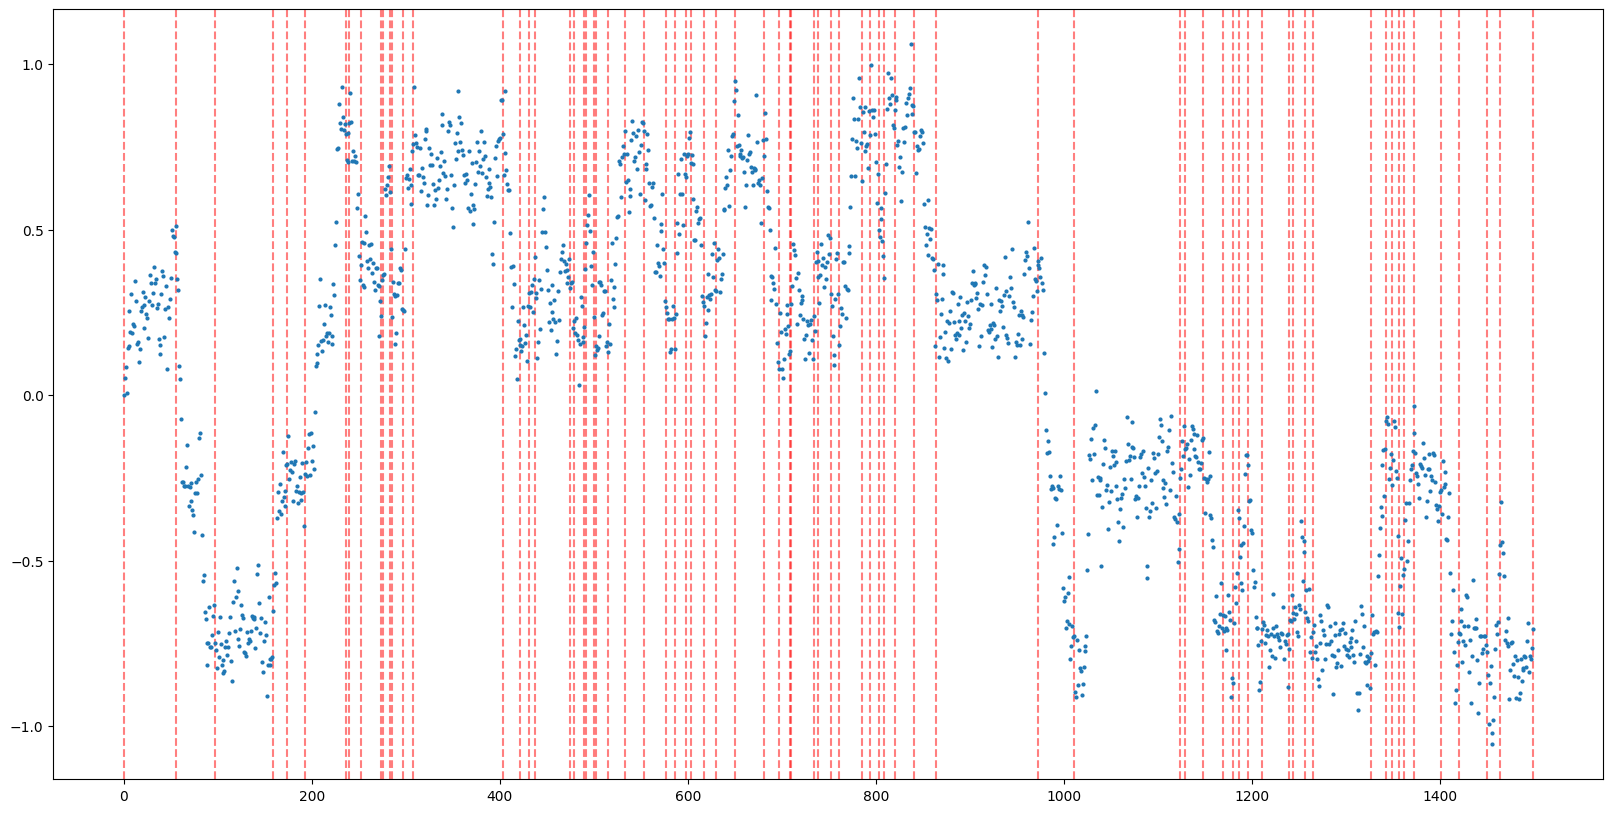

In [4]:
cp_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": cp_sbc.point_labels_})
cps = cp_sbc.change_points_[:,0]
df = cp_df
N = 4
fig = plt.figure(figsize=(20,10))
top_labels = df['label'].value_counts().head(N).index
plt.scatter(df['time'], df['value'], s=4, rasterized=True)
for t in df['time'][cps == 1]:
    plt.axvline(t, color='red', linestyle='--', alpha=0.5, zorder=0)
plt.savefig("prinz-cps.pdf")
plt.show()

In [5]:
T = 10000
l = 0*T
u = 1*T
x = data[l:u]
w=np.array([16])
q=np.array([0.5])
K=4

# fit wit SC
sc_sbc = SegmentBasedCluster(window_size=w, quantile=q, method="spectral", num_clusters=K)
sc_sbc.fit(x)
segment_labels = sc_sbc.segment_labels_
labels = sc_sbc.point_labels_
sc_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": labels})

# refit with ADPC
adpc_sbc = SegmentBasedCluster(window_size=w, quantile=q)
adpc_sbc.fit(x)
segment_labels = adpc_sbc.segment_labels_
labels = adpc_sbc.point_labels_
adpc_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": labels})

100%|████████████████████████████████████| 108345/108345 [00:17<00:00, 6297.00it/s]
/home/dcg/projects/MFPy/mfpy/.venv/lib/python3.9/site-packages/dadapy/kstar.py:101: UserWarning: Careful! The intrinsic dimension is not defined. Computing it unsupervisedly with 'compute_id_2NN()' method
  warnings.warn(


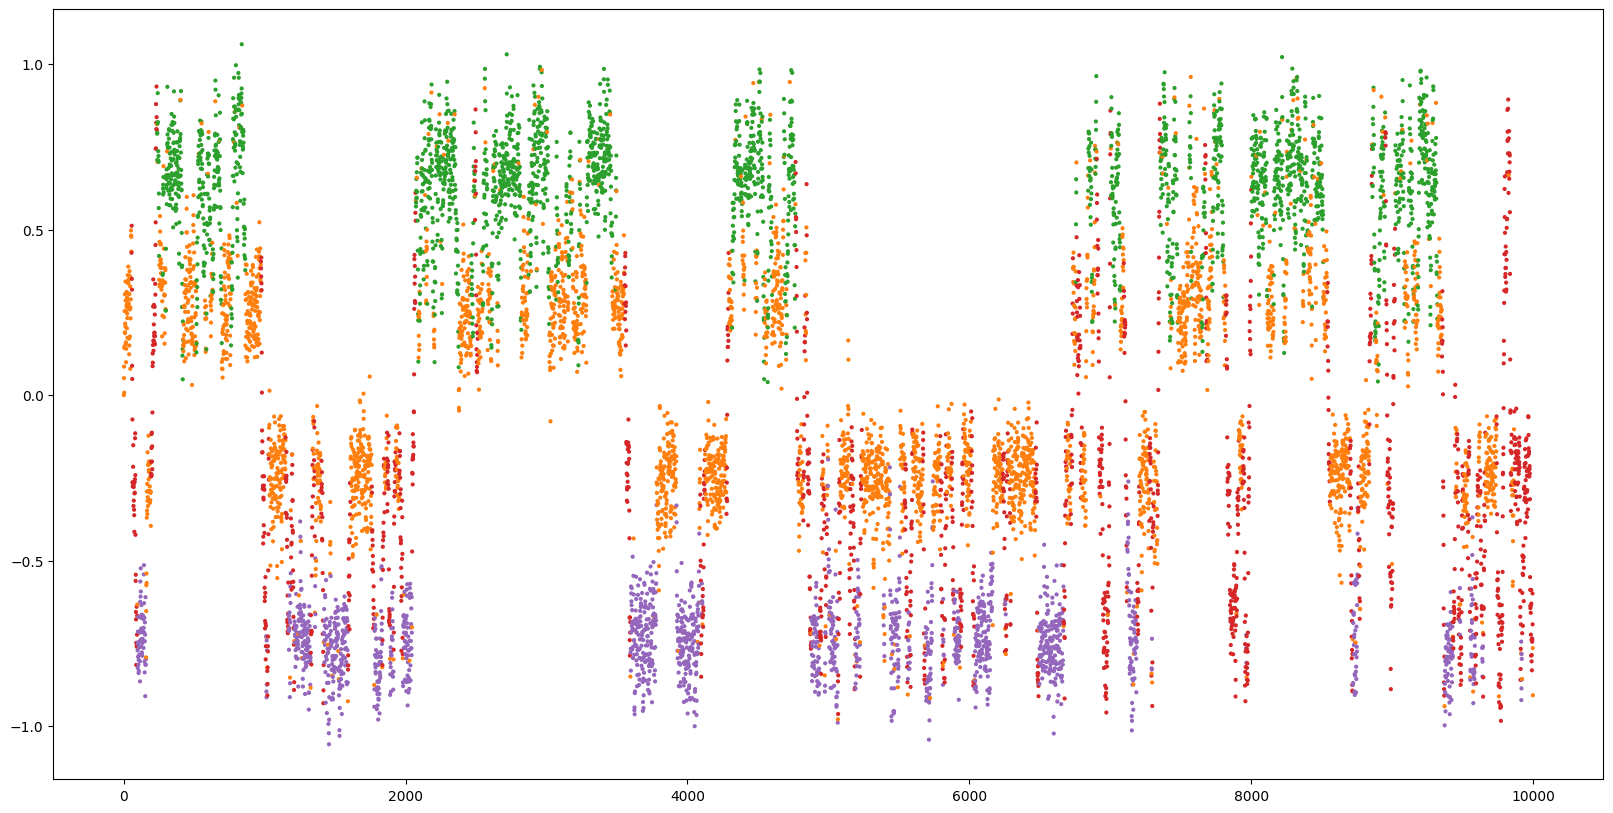

In [6]:
data = sc_df
N = 4
fig = plt.figure(figsize=(20,10))
top_labels = data['label'].value_counts().head(N).index
colors = ['grey' if l not in top_labels else plt.cm.tab10(l) for l in data['label']]
plt.scatter(data['time'], data['value'], c=colors, s=4, rasterized=True)
plt.savefig("prinz-spectral-clustering.pdf")
plt.show()

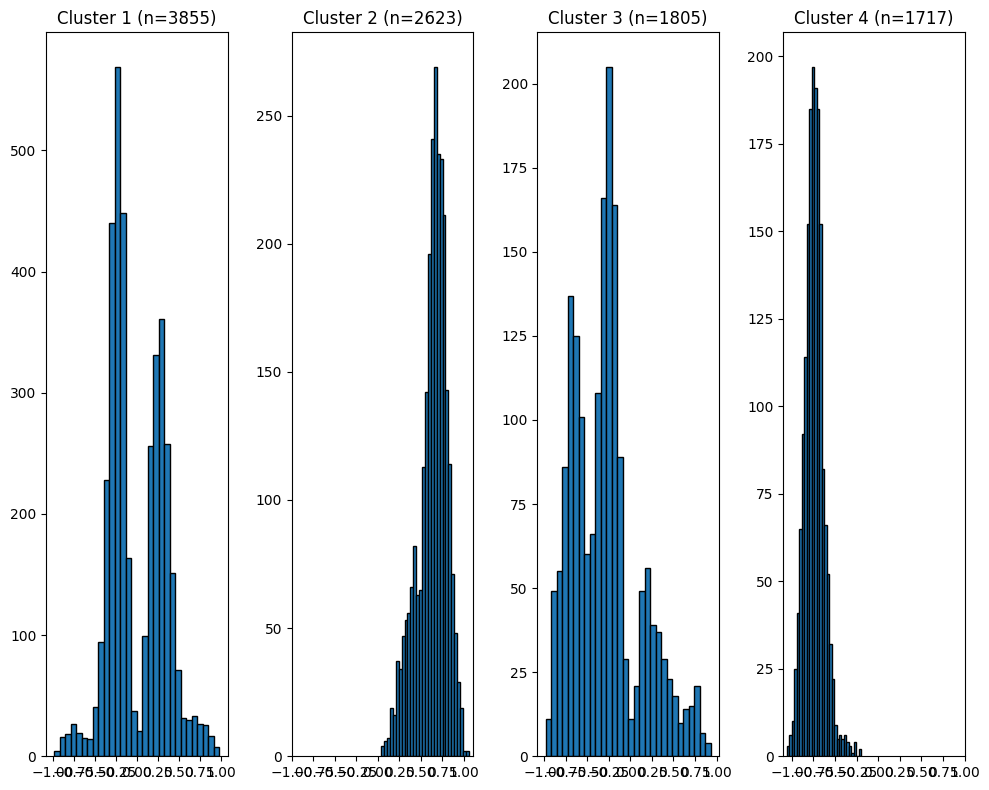

In [7]:
N = 4
top_labels = data['label'].value_counts().head(N).index
fig, axes = plt.subplots(1, 4, figsize=(10, 8))
ticks = [-1.0 + n*0.25 for n in range(9)]
for i, label in enumerate(top_labels):
    #ax = axes[i//2, i%2]
    ax = axes[i]
    cluster_data = data[data['label'] == label]['value']
    ax.hist(cluster_data, bins=30, edgecolor='black')
    ax.set_title(f'Cluster {label} (n={len(cluster_data)})')
    ax.set_xticks(ticks)
plt.tight_layout()
plt.savefig("prinz-spectral-distributions.pdf")
plt.show()

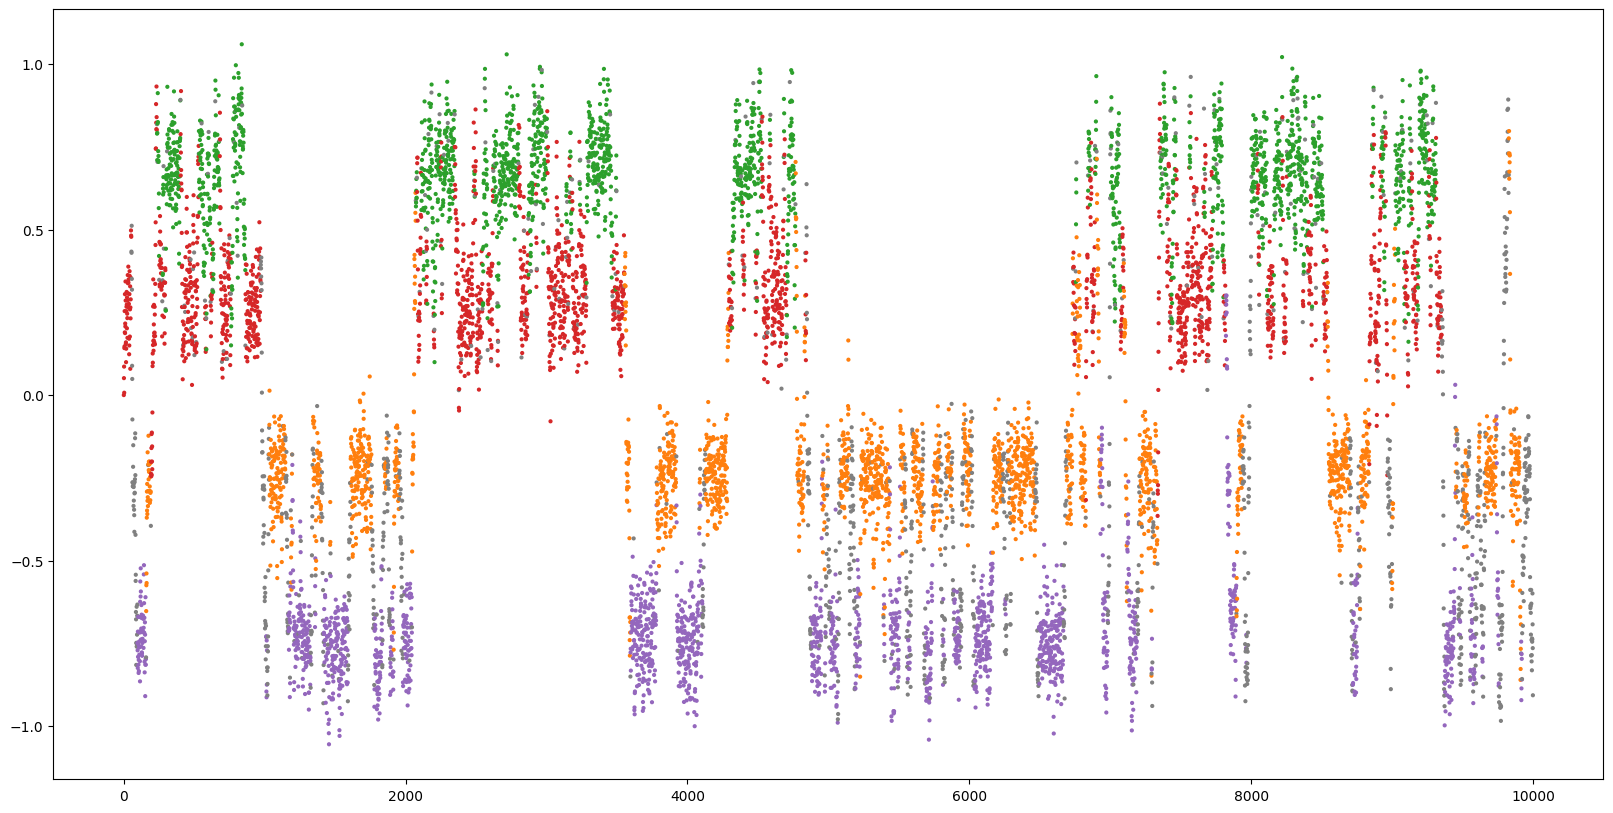

In [8]:
data = adpc_df
N = 4
fig = plt.figure(figsize=(20,10))
top_labels = data['label'].value_counts().head(N).index
colors = ['grey' if l not in top_labels else plt.cm.tab10(l) for l in data['label']]
plt.scatter(data['time'], data['value'], c=colors, s=4, rasterized=True)
plt.savefig("prinz-adpc-clustering.pdf")
plt.show()

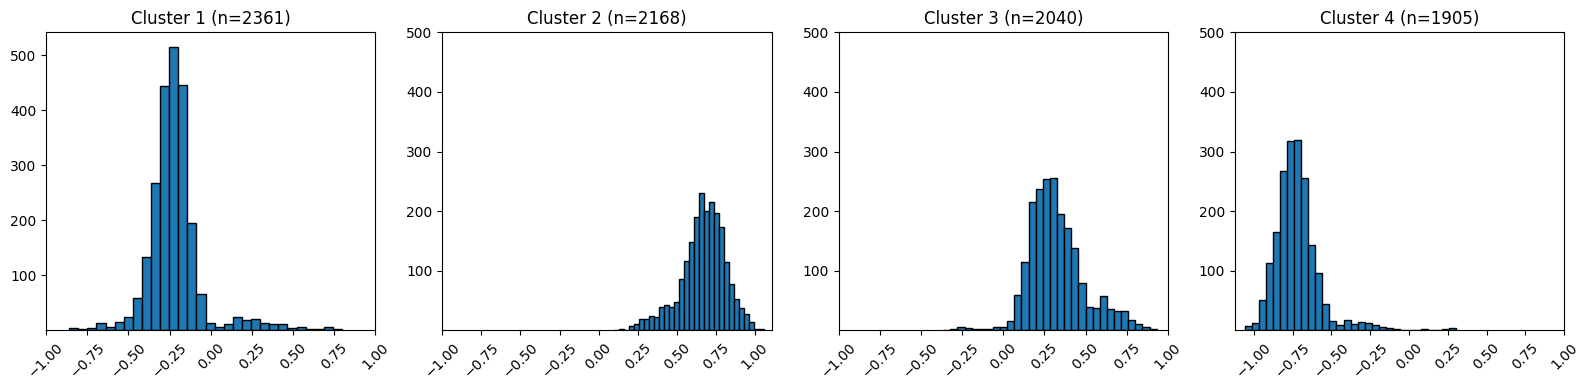

In [9]:
N = 4
top_labels = data['label'].value_counts().head(N).index
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
xticks = [-1.0 + n*0.25 for n in range(9)]
yticks = [n for n in range(100, 600, 100)]
for i, label in enumerate(top_labels):
    ax = axes[i]
    cluster_data = data[data['label'] == label]['value']
    ax.hist(cluster_data, bins=30, edgecolor='black')
    ax.set_title(f'Cluster {label} (n={len(cluster_data)})')
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.tick_params("x",rotation=45)
plt.tight_layout()
plt.savefig("prinz-adpc-distributions.pdf")
plt.show()

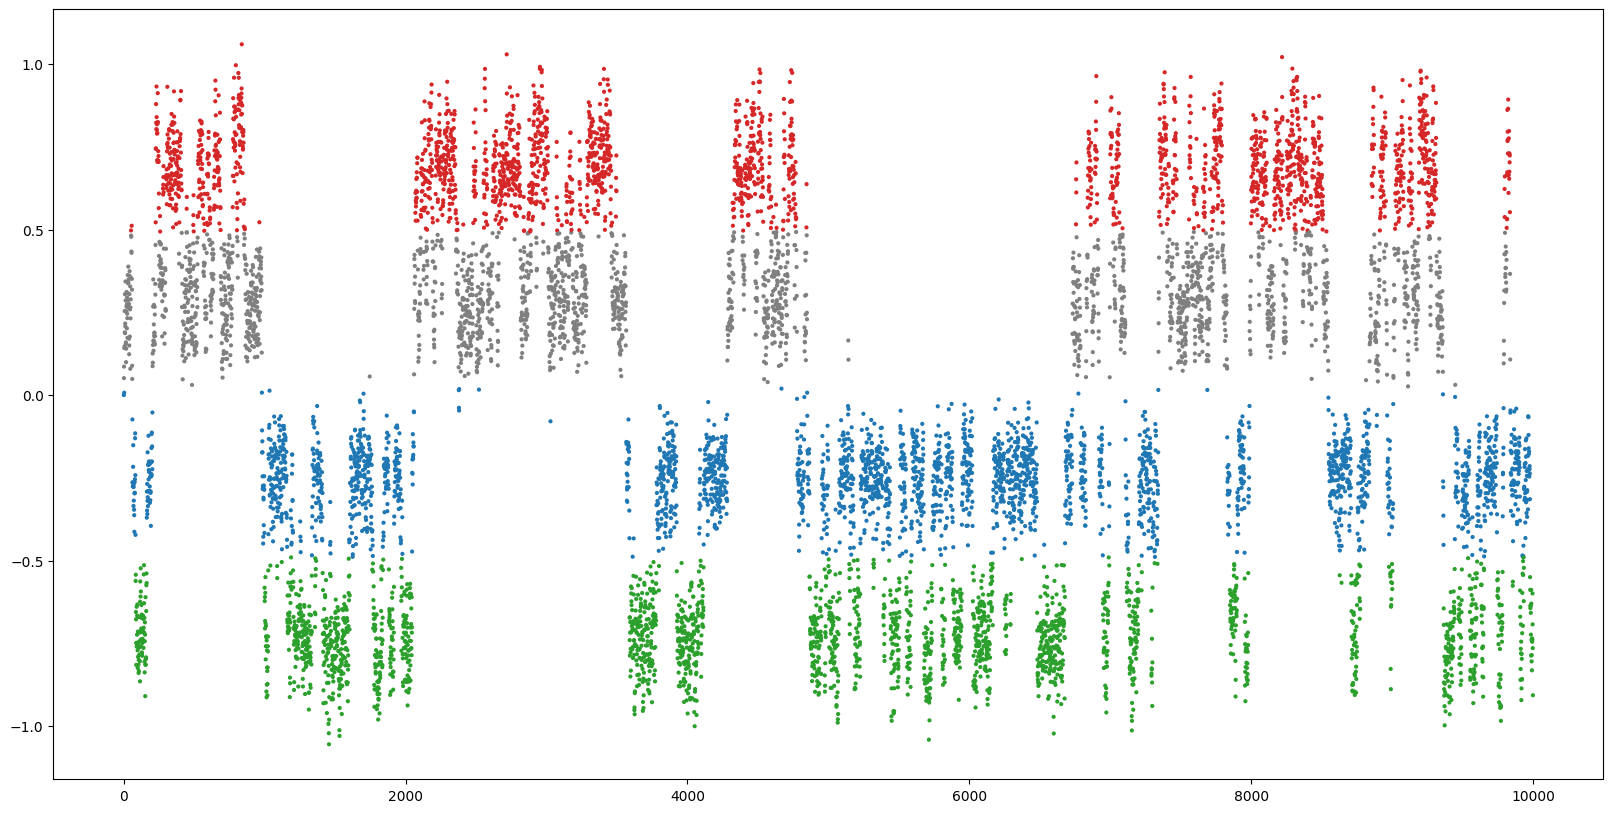

In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(init="k-means++", n_clusters=4, n_init=4)
kmeans.fit(x)
kmeans.labels_.reshape(-1,1)

labels = kmeans.labels_
kmeans_df = pd.DataFrame({"time": range(x.shape[0]), "value": x[:,0], "label": labels})
data = kmeans_df
N = 3
fig = plt.figure(figsize=(20,10))
top_labels = data['label'].value_counts().head(N).index
colors = ['grey' if l not in top_labels else plt.cm.tab10(l) for l in data['label']]
plt.scatter(data['time'], data['value'], c=colors, s=4, rasterized=True)
plt.savefig("prinz-kmeans-clustering.pdf", bbox_inches="tight")
plt.show()

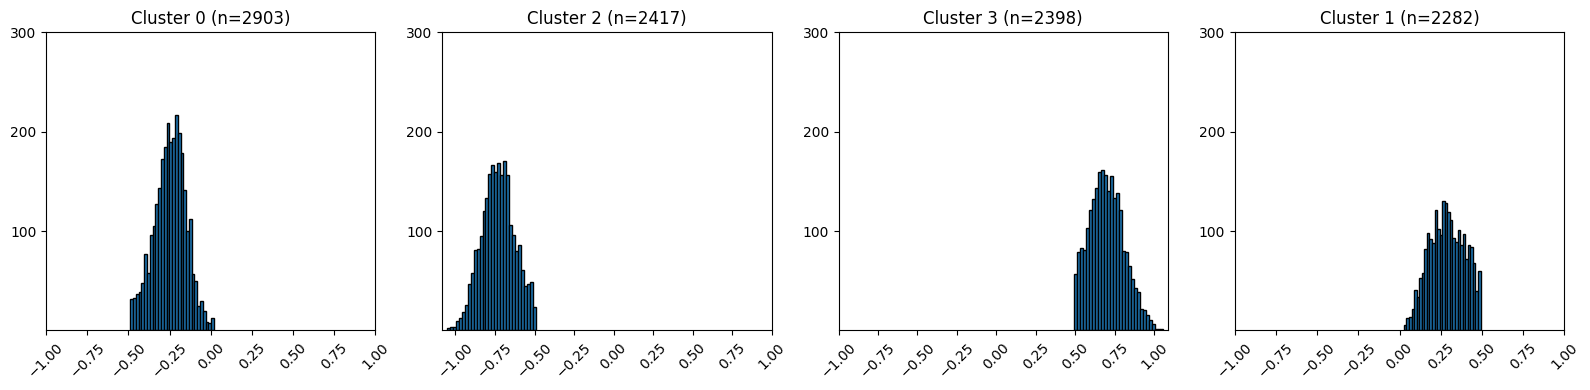

In [11]:
data = kmeans_df
N = 4
top_labels = data['label'].value_counts().head(N).index
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
xticks = [-1.0 + n*0.25 for n in range(9)]
yticks = [n for n in range(100, 400, 100)]
for i, label in enumerate(top_labels):
    ax = axes[i]
    cluster_data = data[data['label'] == label]['value']
    ax.hist(cluster_data, bins=30, edgecolor='black')
    ax.set_title(f'Cluster {label} (n={len(cluster_data)})')
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.tick_params("x",rotation=45)
plt.tight_layout()
plt.savefig("prinz-kmeans-distributions.pdf")
plt.show()